##  Data Access and Setup

### Mounting Google Drive

- We mount Google Drive to access datasets and project files stored there.
- This allows Colab to read/write files directly from your Drive.
- Purpose: Enables loading training, validation, and test datasets into the notebook.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### Setting Up Data Directory and Inspecting Files

- Define the path to the project dataset stored in Google Drive.
- Use `os.walk` to iterate through the folder and count the number of files in each subdirectory.
- Purpose: Verify that the dataset is correctly stored and accessible, and get an overview of the data available for training, validation, and testing.


In [ ]:
import os

# Example path (adjust it to your actual folder location)
data_dir = "/content/drive/MyDrive/oil_spill_detection"

# Check files
for root, dirs, files in os.walk(data_dir):
    print(root, "->", len(files), "files")


/content/drive/MyDrive/oil_spill_detection -> 4 files
/content/drive/MyDrive/oil_spill_detection/train -> 0 files
/content/drive/MyDrive/oil_spill_detection/train/masks -> 811 files
/content/drive/MyDrive/oil_spill_detection/train/images -> 811 files
/content/drive/MyDrive/oil_spill_detection/test -> 0 files
/content/drive/MyDrive/oil_spill_detection/test/images -> 254 files
/content/drive/MyDrive/oil_spill_detection/test/masks -> 254 files
/content/drive/MyDrive/oil_spill_detection/val -> 0 files
/content/drive/MyDrive/oil_spill_detection/val/masks -> 203 files
/content/drive/MyDrive/oil_spill_detection/val/images -> 203 files
/content/drive/MyDrive/oil_spill_detection/models -> 2 files
/content/drive/MyDrive/oil_spill_detection/results -> 8 files
/content/drive/MyDrive/oil_spill_detection/predictions -> 6 files
/content/drive/MyDrive/oil_spill_detection/uploads -> 0 files


### Visualizing Random Sample from Training Dataset

- Select a random image and its corresponding mask from the training dataset.
- Read the image using OpenCV and convert it from BGR to RGB for proper display.
- Read the mask as a grayscale image since it represents binary segmentation (oil spill vs background).
- Use Matplotlib to display the **satellite image** alongside its **oil spill mask**.
- Purpose: Quickly inspect the dataset to ensure images and masks are correctly aligned and readable.


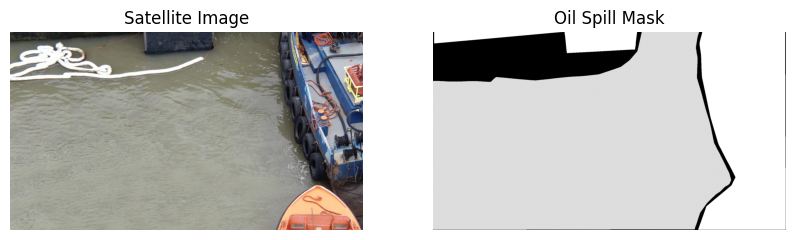

In [ ]:
import matplotlib.pyplot as plt
import cv2
import random
import os

# Example: pick a random image from train dataset
images_dir = "/content/drive/MyDrive/oil_spill_detection/train/images"
masks_dir  = "/content/drive/MyDrive/oil_spill_detection/train/masks"

image_files = sorted(os.listdir(images_dir))
mask_files  = sorted(os.listdir(masks_dir))

# Random sample
idx = random.randint(0, len(image_files)-1)
img_path  = os.path.join(images_dir, image_files[idx])
mask_path = os.path.join(masks_dir, mask_files[idx])

# Read image and mask
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_path, 0)  # grayscale mask

# Plot
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Satellite Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Oil Spill Mask")
plt.axis("off")
plt.show()


### Visualizing Pixel Intensity Distribution

- Convert the selected RGB image to grayscale to analyze intensity values.
- Plot a histogram of pixel intensities using Matplotlib.
- Purpose: Understand the distribution of pixel values in the image, which helps in preprocessing decisions such as normalization or contrast adjustment.


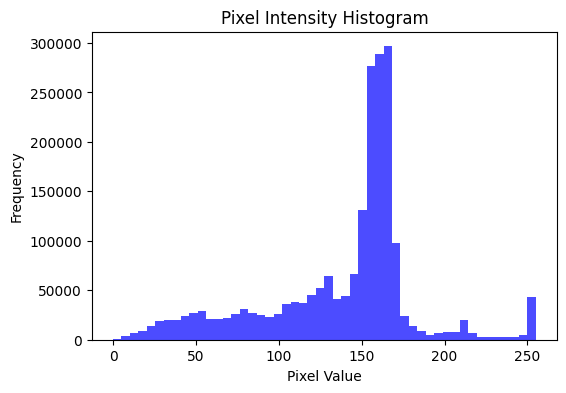

In [ ]:
gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
plt.figure(figsize=(6,4))
plt.hist(gray_img.ravel(), bins=50, color='blue', alpha=0.7)
plt.title("Pixel Intensity Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()


### Image Statistics

- Convert the RGB image to grayscale to calculate statistical measures.
- Compute and print the **mean, standard deviation, minimum, and maximum** pixel values.
- Purpose: Provides insights into image brightness, contrast, and dynamic range, which can guide preprocessing and normalization steps for training.


In [ ]:
import numpy as np
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print("Mean:", np.mean(gray_img), "Std:", np.std(gray_img),
      "Min:", np.min(gray_img), "Max:", np.max(gray_img))


Mean: 137.1878047839506 Std: 44.836127948446034 Min: 0 Max: 255


### Preprocessing Images and Masks

- Define a function `preprocess_image` to prepare images and masks for training.
- **Images**:  
  - Read from file, decode PNG, resize to 256x256, and normalize pixel values to 0-1.
- **Masks**:  
  - Read from file, decode PNG, resize using nearest-neighbor to preserve labels, and convert to binary (0 or 1).
- Purpose: Ensures that input images and masks have consistent size and format, ready for the model training pipeline.


In [ ]:
import tensorflow as tf

IMG_SIZE = (256, 256)

def preprocess_image(img_path, mask_path):
    # Load image
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0  # normalize to 0-1

    # Load mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE, method='nearest')
    mask = tf.cast(mask > 0, tf.float32)  # binary mask

    return img, mask


### Data Augmentation Function

- Define a function `augment` to apply random transformations to images and masks during training.
- **Augmentation techniques include**:  
  - Horizontal and vertical flips.  
  - Rotation by 0°, 90°, 180°, or 270°.  
  - Random brightness and contrast adjustments.  
  - Random zoom by cropping and resizing the image and mask.  
- Purpose: Increases dataset variability, helping the model generalize better and preventing overfitting.


In [ ]:
import tensorflow as tf

def augment(img, mask):
    # --- Random horizontal flip ---
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)

    # --- Random vertical flip ---
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)

    # --- Random rotation (0°, 90°, 180°, 270°) ---
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    mask = tf.image.rot90(mask, k)

    # --- Random brightness adjustment ---
    img = tf.image.random_brightness(img, max_delta=0.2)  # delta=0.2 means +/-20% brightness

    # --- Random contrast adjustment ---
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)  # adjust contrast by 0.8-1.2x

    # --- Random zoom ---
    # Randomly crop 80-100% of the image and resize back to original
    scale = tf.random.uniform([], 0.8, 1.0)
    h, w = tf.shape(img)[0], tf.shape(img)[1]
    new_h, new_w = tf.cast(scale * tf.cast(h, tf.float32), tf.int32), tf.cast(scale * tf.cast(w, tf.float32), tf.int32)

    img = tf.image.random_crop(img, size=[new_h, new_w, 3])
    mask = tf.image.random_crop(mask, size=[new_h, new_w, 1])

    img = tf.image.resize(img, [h, w])
    mask = tf.image.resize(mask, [h, w], method='nearest')

    return img, mask


### Creating Dataset Pipelines

1. **Load and Match Paths**  
- Define directories for training, validation, and test images and masks.  
- Use the `load_paths` function to align images and masks by filename.  
- Print dataset sizes to verify correct loading.

2. **Define Dataset Pipeline**  
- Use `tf.data.Dataset` to efficiently load, preprocess, and batch images and masks.  
- Apply `preprocess_image` to resize and normalize images and convert masks to binary.  
- Apply `augment` for training data to increase variability.  
- Shuffle training data and batch datasets for efficient GPU usage.  
- Prefetch to improve performance during training.

3. **Create Datasets**  
- `train_dataset`: used for model training with augmentation and shuffling.  
- `val_dataset`: used for validation without augmentation or shuffling.  
- `test_dataset`: used for final evaluation without augmentation or shuffling.

✅ Purpose: Prepares the data for model training, validation, and testing in an efficient and reproducible pipeline.



In [ ]:
import glob

# Function to load and match paths
def load_paths(img_dir, mask_dir):
    img_paths = sorted(glob.glob(img_dir + "/*.*"))
    mask_paths = sorted(glob.glob(mask_dir + "/*.*"))

    # Match by filename
    def base(fn): return os.path.splitext(os.path.basename(fn))[0]
    img_map = {base(f): f for f in img_paths}
    mask_map = {base(f): f for f in mask_paths}

    common_keys = list(set(img_map.keys()) & set(mask_map.keys()))
    img_paths = [img_map[k] for k in common_keys]
    mask_paths = [mask_map[k] for k in common_keys]

    return img_paths, mask_paths

# Paths
TRAIN_IMG_DIR = "/content/drive/MyDrive/oil_spill_detection/train/images"
TRAIN_MASK_DIR = "/content/drive/MyDrive/oil_spill_detection/train/masks"
VAL_IMG_DIR   = "/content/drive/MyDrive/oil_spill_detection/val/images"
VAL_MASK_DIR  = "/content/drive/MyDrive/oil_spill_detection/val/masks"
TEST_IMG_DIR  = "/content/drive/MyDrive/oil_spill_detection/test/images"
TEST_MASK_DIR = "/content/drive/MyDrive/oil_spill_detection/test/masks"

train_img, train_mask = load_paths(TRAIN_IMG_DIR, TRAIN_MASK_DIR)
val_img, val_mask     = load_paths(VAL_IMG_DIR, VAL_MASK_DIR)
test_img, test_mask   = load_paths(TEST_IMG_DIR, TEST_MASK_DIR)

print("Train:", len(train_img), "Val:", len(val_img), "Test:", len(test_img))

# Dataset pipeline
BATCH_SIZE = 8

def make_dataset(img_list, mask_list, batch_size=BATCH_SIZE, shuffle=True, augment_data=True):
    dataset = tf.data.Dataset.from_tensor_slices((img_list, mask_list))
    dataset = dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        dataset = dataset.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        dataset = dataset.shuffle(buffer_size=100, reshuffle_each_iteration=True)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_dataset = make_dataset(train_img, train_mask)
val_dataset   = make_dataset(val_img, val_mask, shuffle=False, augment_data=False)
test_dataset  = make_dataset(test_img, test_mask, shuffle=False, augment_data=False)

print("✅ Datasets ready for training!")


Train: 811 Val: 203 Test: 254
✅ Datasets ready for training!


### Visualizing a Batch of Images and Masks

- Define a function `visualize_batch` to display multiple images and their corresponding masks from a dataset batch.
- Plots **satellite images** on the top row and their **oil spill masks** on the bottom row.
- Purpose: Quickly inspect a batch of data to ensure that preprocessing, augmentation, and dataset pipeline are working correctly.
- Helps verify that images and masks are properly aligned and ready for training.


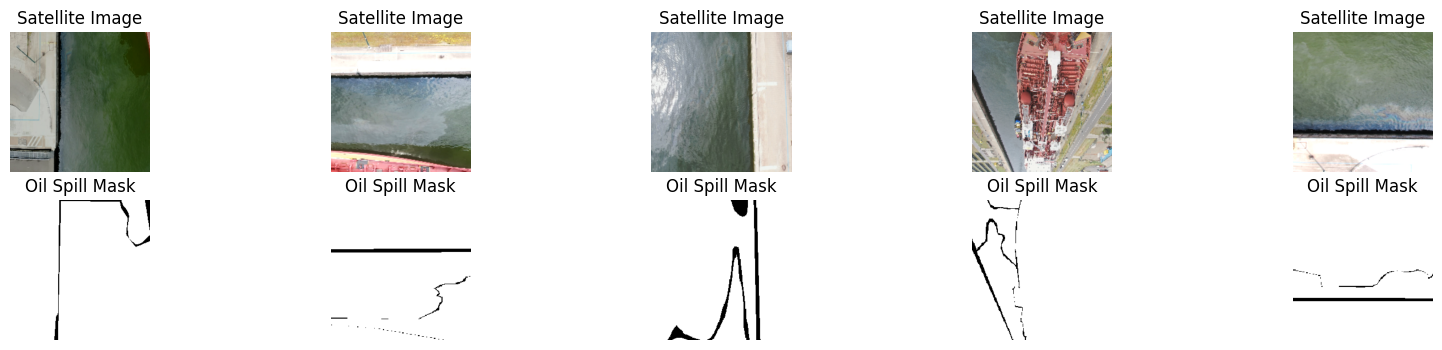

In [ ]:
def visualize_batch(dataset, num_samples=5):
    for img_batch, mask_batch in dataset.take(1):
        plt.figure(figsize=(num_samples*4, 4))
        for i in range(num_samples):
            img = img_batch[i].numpy()
            mask = mask_batch[i].numpy().squeeze()
            plt.subplot(2, num_samples, i+1)
            plt.imshow(img)
            plt.title("Satellite Image")
            plt.axis("off")
            plt.subplot(2, num_samples, num_samples+i+1)
            plt.imshow(mask, cmap="gray")
            plt.title("Oil Spill Mask")
            plt.axis("off")
        plt.show()

# ✅ Run visualization
visualize_batch(train_dataset, num_samples=5)

##  Model Development


## Imports

- Import libraries required for building and training the deep learning model:
  - `tensorflow` and `keras` for model creation and training.
  - `backend as K` for defining custom metrics and loss functions.
  - `matplotlib.pyplot` for visualization of results and predictions.
  - `numpy` for numerical operations and array handling.
  - `skimage.morphology` for post-processing predicted masks.
  - `preprocess_input` from MobileNetV2 to normalize images for transfer learning.
- Purpose: Sets up all necessary tools for model building, training, and evaluation.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
import matplotlib.pyplot as plt
import numpy as np
from skimage import morphology
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

### Preprocessing Function

We define a function `preprocess_for_model` to:

- Normalize input images using MobileNetV2 preprocessing.
- Ensure masks are in float32 format for training.
- Purpose: Prepare images and masks so they are compatible with the model architecture.


In [ ]:
def preprocess_for_model(img, mask):
    img = preprocess_input(img)  # MobileNetV2 compatible normalization
    return img, mask


### U-Net Model Construction

- We build a U-Net segmentation model using MobileNetV2 as the encoder.
- Skip connections from the encoder to the decoder help preserve spatial details.
- The decoder upsamples features to reconstruct the binary oil spill mask.
- Encoder layers are initially frozen to leverage transfer learning.
- The output layer uses sigmoid activation to predict oil spill regions (0 or 1).


In [ ]:
def build_unet(input_size=(256,256,3)):
    """
    Returns a U-Net model with MobileNetV2 as encoder and custom decoder.
    Encoder is frozen initially for transfer learning.
    """
    # Pretrained MobileNetV2 as encoder
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_size, include_top=False, weights="imagenet"
    )

    # Encoder skip connections
    skips = [
        base_model.get_layer("block_1_expand_relu").output,   # 128x128
        base_model.get_layer("block_3_expand_relu").output,   # 64x64
        base_model.get_layer("block_6_expand_relu").output,   # 32x32
        base_model.get_layer("block_13_expand_relu").output,  # 16x16
    ]
    encoder_output = base_model.get_layer("block_16_project").output  # 8x8

    # Decoder: Upsample and combine with skip connections
    x = encoder_output
    decoder_filters = [512, 256, 128, 64]
    for i, skip in enumerate(reversed(skips)):
        x = layers.Conv2DTranspose(decoder_filters[i], (3,3), strides=2, padding="same")(x)
        x = layers.concatenate([x, skip])
        x = layers.Conv2D(decoder_filters[i], (3,3), activation="relu", padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(decoder_filters[i], (3,3), activation="relu", padding="same")(x)
        x = layers.BatchNormalization()(x)

    # Final upsample to match input size (256x256x1)
    x = layers.Conv2DTranspose(32, (3,3), strides=2, padding="same")(x)
    x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)

    outputs = layers.Conv2D(1, (1,1), activation="sigmoid")(x)

    # Create model
    model = models.Model(inputs=base_model.input, outputs=outputs)

    # Freeze encoder layers initially
    for layer in base_model.layers:
        layer.trainable = False

    return model

# 4️⃣ Instantiate and summarize model
model = build_unet(input_size=(256,256,3))
model.summary()

/tmp/ipython-input-2610354362.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 14,487,905 (55.27 MB)

 Trainable params: 12,642,017 (48.23 MB)

 Non-trainable params: 1,845,888 (7.04 MB)

## Training and Evaluation


## Metrics & Loss

We define metrics and loss functions:

- **Dice Coefficient** and **IoU**: Measure overlap between predicted masks and ground truth.
- **Dice Loss + IoU Loss + Binary Cross-Entropy**: Combined into `combined_loss` to guide training.
- **Precision, Recall, F1-Score**: Evaluate prediction quality beyond accuracy.
- Purpose: Ensure the model learns both pixel-wise accuracy and region-level segmentation.
### Model Compilation

- Compiled using Adam optimizer and combined loss function.
- Metrics include accuracy, Dice, IoU, precision, recall, and F1-score.
- Purpose: Prepares the model for training and evaluation.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras import mixed_precision
import matplotlib.pyplot as plt
# -----------------------------
# 1. Metrics & Loss Functions
# -----------------------------
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def iou_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def iou_loss(y_true, y_pred):
    return 1 - iou_coefficient(y_true, y_pred)

def combined_loss(y_true, y_pred):
    """Binary Crossentropy + Dice + IoU Loss"""
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred) + iou_loss(y_true, y_pred)

def precision_m(y_true, y_pred):
    y_pred = K.round(y_pred)
    tp = K.sum(K.round(y_true * y_pred))
    fp = K.sum(K.round((1 - y_true) * y_pred))
    return tp / (tp + fp + K.epsilon())

def recall_m(y_true, y_pred):
    y_pred = K.round(y_pred)
    tp = K.sum(K.round(y_true * y_pred))
    fn = K.sum(K.round(y_true * (1 - y_pred)))
    return tp / (tp + fn + K.epsilon())

def f1_score(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2 * ((precision * recall) / (precision + recall + K.epsilon()))

# -----------------------------
# 3. Model Compilation
# -----------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=["accuracy", dice_coefficient, iou_coefficient, precision_m, recall_m, f1_score]
)


### Callbacks for Efficient Training

- **ModelCheckpoint**: Saves the best model based on validation loss.
- **EarlyStopping**: Stops training if validation loss does not improve to prevent overfitting.
- **ReduceLROnPlateau**: Reduces learning rate when the model reaches a plateau in validation loss.


In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True, monitor="val_loss"),
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

### Dataset Inspection

- Prints the shape and data type of a batch of images and masks.
- Purpose: Verify that the dataset is loaded correctly and compatible with the model.


In [ ]:
for x, y in train_dataset.take(1):
    print("Image batch:", x.shape, x.dtype)
    print("Mask batch:", y.shape, y.dtype)

Image batch: (8, 256, 256, 3) <dtype: 'float32'>
Mask batch: (8, 256, 256, 1) <dtype: 'float32'>


 Training

### Model Training

- Trains the model on the training dataset with validation on the validation dataset.
- Uses callbacks for efficient training and to avoid overfitting.
- Purpose: Teach the model to accurately predict oil spill regions.


In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=callbacks
)


Epoch 1/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7232 - dice_coefficient: 0.6795 - f1_score: 0.8325 - iou_coefficient: 0.5146 - loss: 1.5658 - precision_m: 0.9701 - recall_m: 0.7363

102/102 ━━━━━━━━━━━━━━━━━━━━ 334s 3s/step - accuracy: 0.7240 - dice_coefficient: 0.6795 - f1_score: 0.8330 - iou_coefficient: 0.5147 - loss: 1.5653 - precision_m: 0.9701 - recall_m: 0.7372 - val_accuracy: 0.2201 - val_dice_coefficient: 0.6366 - val_f1_score: 0.3277 - val_iou_coefficient: 0.4669 - val_loss: 1.6378 - val_precision_m: 0.9491 - val_recall_m: 0.1981 - learning_rate: 1.0000e-04
Epoch 2/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.9136 - dice_coefficient: 0.7178 - f1_score: 0.9542 - iou_coefficient: 0.5598 - loss: 1.4094 - precision_m: 0.9729 - recall_m: 0.9366

102/102 ━━━━━━━━━━━━━━━━━━━━ 46s 408ms/step - accuracy: 0.9137 - dice_coefficient: 0.7178 - f1_score: 0.9542 - iou_coefficient: 0.5599 - loss: 1.4092 - precision_m: 0.9729 - recall_m: 0.9367 - val_accuracy: 0.8434 - val_dice_coefficient: 0.6954 - val_f1_score: 0.9132 - val_iou_coefficient: 0.5331 - val_loss: 1.5630 - val_precision_m: 0.9728 - val_recall_m: 0.8612 - learning_rate: 1.0000e-04
Epoch 3/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 42s 358ms/step - accuracy: 0.9289 - dice_coefficient: 0.7387 - f1_score: 0.9626 - iou_coefficient: 0.5858 - loss: 1.3325 - precision_m: 0.9711 - recall_m: 0.9547 - val_accuracy: 0.9090 - val_dice_coefficient: 0.7296 - val_f1_score: 0.9513 - val_iou_coefficient: 0.5745 - val_loss: 2.0472 - val_precision_m: 0.9719 - val_recall_m: 0.9323 - learning_rate: 1.0000e-04
Epoch 4/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.9445 - dice_coefficient: 0.7604 - f1_score: 0.9711 - iou_coefficient: 0.6135 - loss: 1.2389 - precision_m: 0.9687 - recall_m: 0.9739

102/102 ━━━━━━━━━━━━━━━━━━━━ 82s 379ms/step - accuracy: 0.9445 - dice_coefficient: 0.7604 - f1_score: 0.9711 - iou_coefficient: 0.6135 - loss: 1.2388 - precision_m: 0.9687 - recall_m: 0.9739 - val_accuracy: 0.9292 - val_dice_coefficient: 0.7641 - val_f1_score: 0.9628 - val_iou_coefficient: 0.6184 - val_loss: 1.3058 - val_precision_m: 0.9710 - val_recall_m: 0.9552 - learning_rate: 1.0000e-04
Epoch 5/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.9465 - dice_coefficient: 0.7724 - f1_score: 0.9722 - iou_coefficient: 0.6294 - loss: 1.1681 - precision_m: 0.9678 - recall_m: 0.9770

102/102 ━━━━━━━━━━━━━━━━━━━━ 86s 412ms/step - accuracy: 0.9465 - dice_coefficient: 0.7725 - f1_score: 0.9722 - iou_coefficient: 0.6294 - loss: 1.1679 - precision_m: 0.9678 - recall_m: 0.9770 - val_accuracy: 0.9511 - val_dice_coefficient: 0.7854 - val_f1_score: 0.9746 - val_iou_coefficient: 0.6468 - val_loss: 1.2998 - val_precision_m: 0.9665 - val_recall_m: 0.9834 - learning_rate: 1.0000e-04
Epoch 6/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.9521 - dice_coefficient: 0.7906 - f1_score: 0.9751 - iou_coefficient: 0.6538 - loss: 1.0881 - precision_m: 0.9655 - recall_m: 0.9854

...

102/102 ━━━━━━━━━━━━━━━━━━━━ 43s 366ms/step - accuracy: 0.9636 - dice_coefficient: 0.9554 - f1_score: 0.9812 - iou_coefficient: 0.9150 - loss: 0.2747 - precision_m: 0.9648 - recall_m: 0.9986 - val_accuracy: 0.9600 - val_dice_coefficient: 0.9583 - val_f1_score: 0.9795 - val_iou_coefficient: 0.9201 - val_loss: 0.2626 - val_precision_m: 0.9603 - val_recall_m: 0.9998 - learning_rate: 1.0000e-04
Epoch 26/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 83s 400ms/step - accuracy: 0.9658 - dice_coefficient: 0.9582 - f1_score: 0.9824 - iou_coefficient: 0.9199 - loss: 0.2583 - precision_m: 0.9669 - recall_m: 0.9988 - val_accuracy: 0.9597 - val_dice_coefficient: 0.9247 - val_f1_score: 0.9793 - val_iou_coefficient: 0.8603 - val_loss: 0.5206 - val_precision_m: 0.9601 - val_recall_m: 0.9998 - learning_rate: 1.0000e-04
Epoch 27/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.9631 - dice_coefficient: 0.9589 - f1_score: 0.9810 - iou_coefficient: 0.9213 - loss: 0.2655 - precision_m: 0.9638 - recall_m: 0.999

102/102 ━━━━━━━━━━━━━━━━━━━━ 80s 378ms/step - accuracy: 0.9631 - dice_coefficient: 0.9589 - f1_score: 0.9810 - iou_coefficient: 0.9213 - loss: 0.2656 - precision_m: 0.9638 - recall_m: 0.9992 - val_accuracy: 0.9613 - val_dice_coefficient: 0.9585 - val_f1_score: 0.9801 - val_iou_coefficient: 0.9206 - val_loss: 0.2582 - val_precision_m: 0.9618 - val_recall_m: 0.9995 - learning_rate: 1.0000e-04
Epoch 28/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 81s 374ms/step - accuracy: 0.9639 - dice_coefficient: 0.9609 - f1_score: 0.9813 - iou_coefficient: 0.9251 - loss: 0.2536 - precision_m: 0.9649 - recall_m: 0.9988 - val_accuracy: 0.9597 - val_dice_coefficient: 0.9473 - val_f1_score: 0.9793 - val_iou_coefficient: 0.9001 - val_loss: 0.3226 - val_precision_m: 0.9599 - val_recall_m: 1.0000 - learning_rate: 1.0000e-04
Epoch 29/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 45s 402ms/step - accuracy: 0.9617 - dice_coefficient: 0.9609 - f1_score: 0.9803 - iou_coefficient: 0.9250 - loss: 0.2565 - precision_m: 0.9627 - recall_m: 0.99

102/102 ━━━━━━━━━━━━━━━━━━━━ 47s 413ms/step - accuracy: 0.9625 - dice_coefficient: 0.9638 - f1_score: 0.9807 - iou_coefficient: 0.9304 - loss: 0.2438 - precision_m: 0.9632 - recall_m: 0.9992 - val_accuracy: 0.9606 - val_dice_coefficient: 0.9651 - val_f1_score: 0.9797 - val_iou_coefficient: 0.9328 - val_loss: 0.2362 - val_precision_m: 0.9612 - val_recall_m: 0.9994 - learning_rate: 5.0000e-05
Epoch 32/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 77s 377ms/step - accuracy: 0.9633 - dice_coefficient: 0.9638 - f1_score: 0.9811 - iou_coefficient: 0.9303 - loss: 0.2439 - precision_m: 0.9645 - recall_m: 0.9986 - val_accuracy: 0.9601 - val_dice_coefficient: 0.9640 - val_f1_score: 0.9795 - val_iou_coefficient: 0.9308 - val_loss: 0.2441 - val_precision_m: 0.9610 - val_recall_m: 0.9992 - learning_rate: 5.0000e-05
Epoch 33/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 42s 376ms/step - accuracy: 0.9617 - dice_coefficient: 0.9640 - f1_score: 0.9803 - iou_coefficient: 0.9308 - loss: 0.2432 - precision_m: 0.9621 - recall_m: 0.99

102/102 ━━━━━━━━━━━━━━━━━━━━ 84s 409ms/step - accuracy: 0.9623 - dice_coefficient: 0.9653 - f1_score: 0.9806 - iou_coefficient: 0.9332 - loss: 0.2351 - precision_m: 0.9633 - recall_m: 0.9989 - val_accuracy: 0.9597 - val_dice_coefficient: 0.9664 - val_f1_score: 0.9793 - val_iou_coefficient: 0.9354 - val_loss: 0.2358 - val_precision_m: 0.9599 - val_recall_m: 1.0000 - learning_rate: 2.5000e-05
Epoch 37/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.9634 - dice_coefficient: 0.9663 - f1_score: 0.9811 - iou_coefficient: 0.9350 - loss: 0.2293 - precision_m: 0.9645 - recall_m: 0.9988

102/102 ━━━━━━━━━━━━━━━━━━━━ 83s 410ms/step - accuracy: 0.9634 - dice_coefficient: 0.9663 - f1_score: 0.9811 - iou_coefficient: 0.9350 - loss: 0.2294 - precision_m: 0.9644 - recall_m: 0.9988 - val_accuracy: 0.9613 - val_dice_coefficient: 0.9675 - val_f1_score: 0.9801 - val_iou_coefficient: 0.9373 - val_loss: 0.2245 - val_precision_m: 0.9617 - val_recall_m: 0.9996 - learning_rate: 2.5000e-05
Epoch 38/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 77s 374ms/step - accuracy: 0.9630 - dice_coefficient: 0.9662 - f1_score: 0.9810 - iou_coefficient: 0.9348 - loss: 0.2299 - precision_m: 0.9645 - recall_m: 0.9984 - val_accuracy: 0.9620 - val_dice_coefficient: 0.9610 - val_f1_score: 0.9804 - val_iou_coefficient: 0.9251 - val_loss: 0.2457 - val_precision_m: 0.9633 - val_recall_m: 0.9984 - learning_rate: 2.5000e-05
Epoch 39/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 43s 378ms/step - accuracy: 0.9644 - dice_coefficient: 0.9669 - f1_score: 0.9817 - iou_coefficient: 0.9362 - loss: 0.2267 - precision_m: 0.9654 - recall_m: 0.99

In [ ]:
from tensorflow.keras.models import load_model

model = load_model(
    "/content/best_model.h5",
    compile=False
)
model.save("/content/drive/MyDrive/oil_spill_detection/final_model.keras")
print("✅ Model reloaded and saved in new Keras format!")


✅ Model reloaded and saved in new Keras format!


### Training Curves

- Plots loss, accuracy, Dice, and IoU for both training and validation datasets.
- Purpose: Visualize how the model learns over epochs and detect overfitting or underfitting.


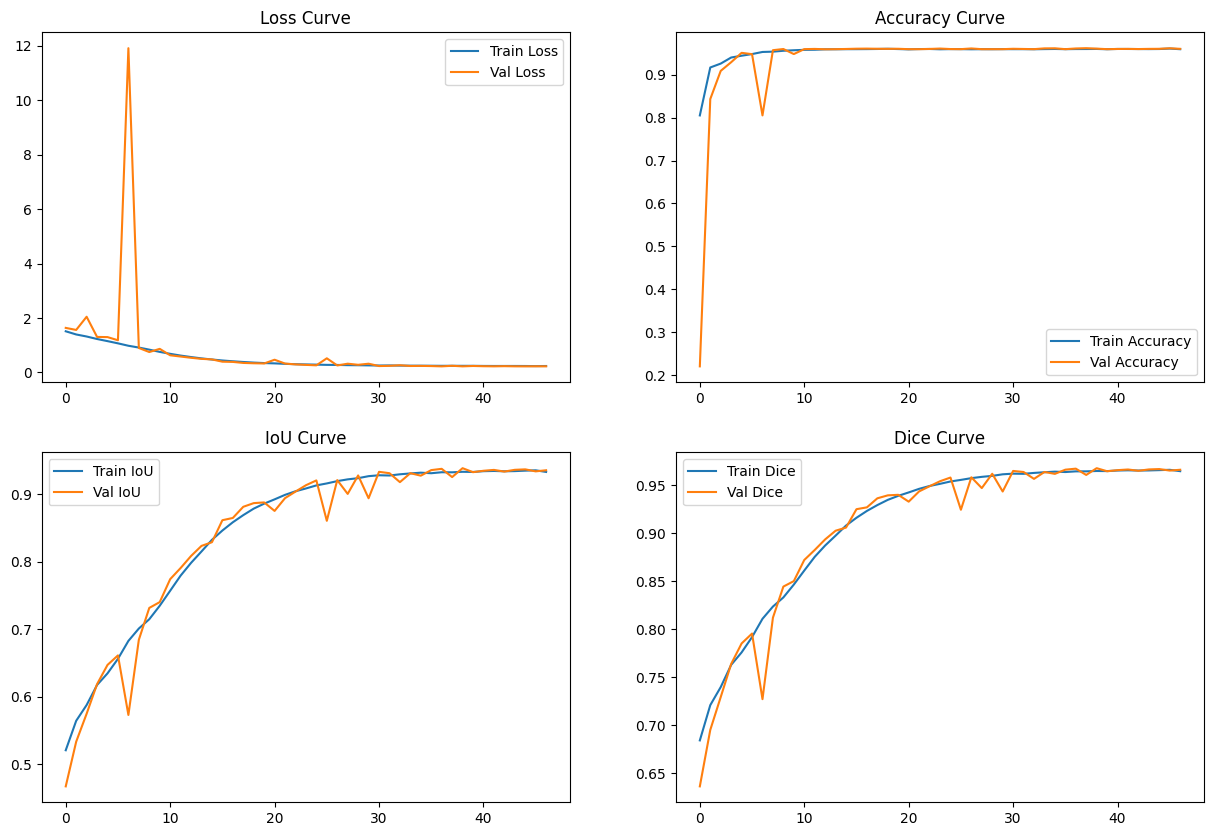

In [ ]:
# ==========================
# Training Curves (Accuracy, Loss, IoU, Dice, F1)
# ==========================
plt.figure(figsize=(15, 10))

# Loss
plt.subplot(2,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.legend()

# Accuracy
plt.subplot(2,2,2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy Curve")
plt.legend()

# IoU
plt.subplot(2,2,3)
plt.plot(history.history["iou_coefficient"], label="Train IoU")
plt.plot(history.history["val_iou_coefficient"], label="Val IoU")
plt.title("IoU Curve")
plt.legend()

# Dice
plt.subplot(2,2,4)
plt.plot(history.history["dice_coefficient"], label="Train Dice")
plt.plot(history.history["val_dice_coefficient"], label="Val Dice")
plt.title("Dice Curve")
plt.legend()

plt.show()


Post-Processing

### Post-Processing Predicted Masks

- Apply thresholding and morphological operations (opening & closing) to clean predicted masks.
- Purpose: Remove small artifacts and refine predicted oil spill regions for better accuracy.


In [ ]:
import cv2
def postprocess_mask(mask):
    mask = (mask > 0.5).astype('uint8')
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask

### Model Evaluation on Test Data

- Uses `model.evaluate` to calculate metrics like loss, accuracy, Dice, IoU, precision, recall, and F1-score on unseen test data.
- Purpose: Quantitatively measure the performance of the trained model.


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=[
        'accuracy',
        dice_coefficient,
        iou_coefficient,
        precision_m,
        recall_m,
        f1_score
    ]
)
print("✅ Model compiled successfully!")


✅ Model compiled successfully!


In [ ]:
results = model.evaluate(test_dataset)
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 130s 4s/step - accuracy: 0.9622 - dice_coefficient: 0.9668 - f1_score: 0.9806 - iou_coefficient: 0.9359 - loss: 0.2325 - precision_m: 0.9627 - recall_m: 0.9993
loss: 0.2320
compile_metrics: 0.9620


### Visualization of Predictions

- Shows **original image**, **ground truth mask**, and **predicted mask overlayed** on the image.
- Red overlay represents predicted oil spill regions.
- Post-processing is applied to clean the mask before overlay.
- Purpose: Visually assess the model’s predictions and communicate results effectively.


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


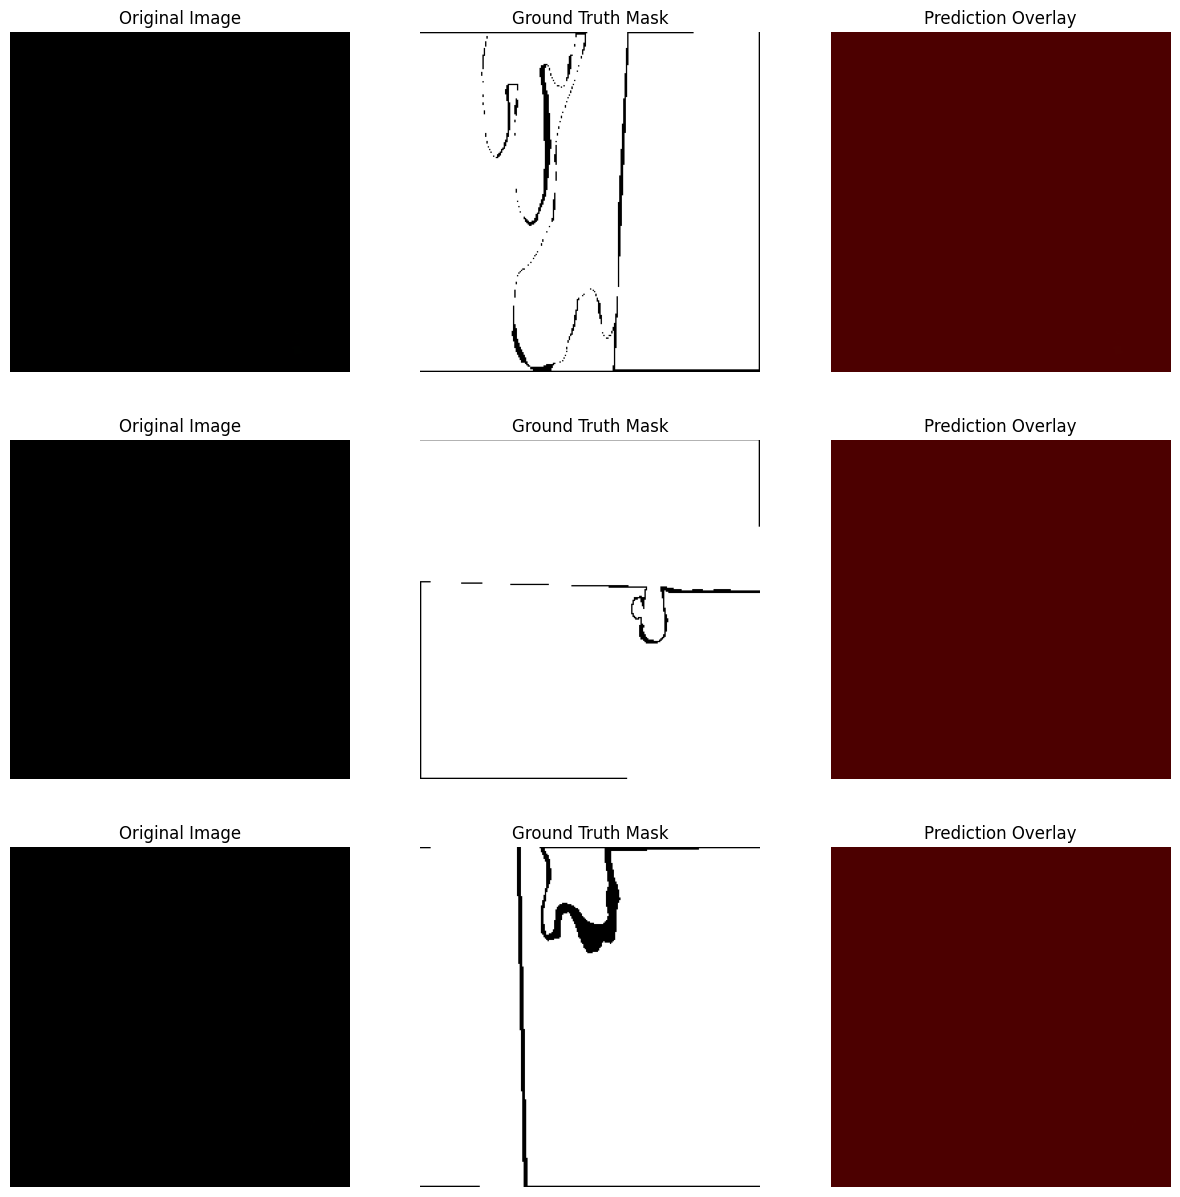

In [ ]:
def visualize_predictions_overlay(model, dataset, num_samples=3):
    for images, masks in dataset.take(1):
        preds = model.predict(images)

        plt.figure(figsize=(15, num_samples*5))
        for i in range(num_samples):
            img = images[i].numpy().astype("uint8")
            true_mask = masks[i].numpy().squeeze()
            pred_mask = (preds[i] > 0.5).astype("uint8").squeeze()

            # Overlay prediction (red) on original image
            overlay = img.copy()
            overlay[pred_mask == 1] = [255, 0, 0]  # red for spill
            blended = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)

            # Show results
            plt.subplot(num_samples, 3, i*3+1)
            plt.imshow(img)
            plt.title("Original Image")
            plt.axis("off")

            plt.subplot(num_samples, 3, i*3+2)
            plt.imshow(true_mask, cmap="gray")
            plt.title("Ground Truth Mask")
            plt.axis("off")

            plt.subplot(num_samples, 3, i*3+3)
            plt.imshow(blended)
            plt.title("Prediction Overlay")
            plt.axis("off")
        plt.show()

# Call function
visualize_predictions_overlay(model, test_dataset, num_samples=3)


Side-by-side Comparison

1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


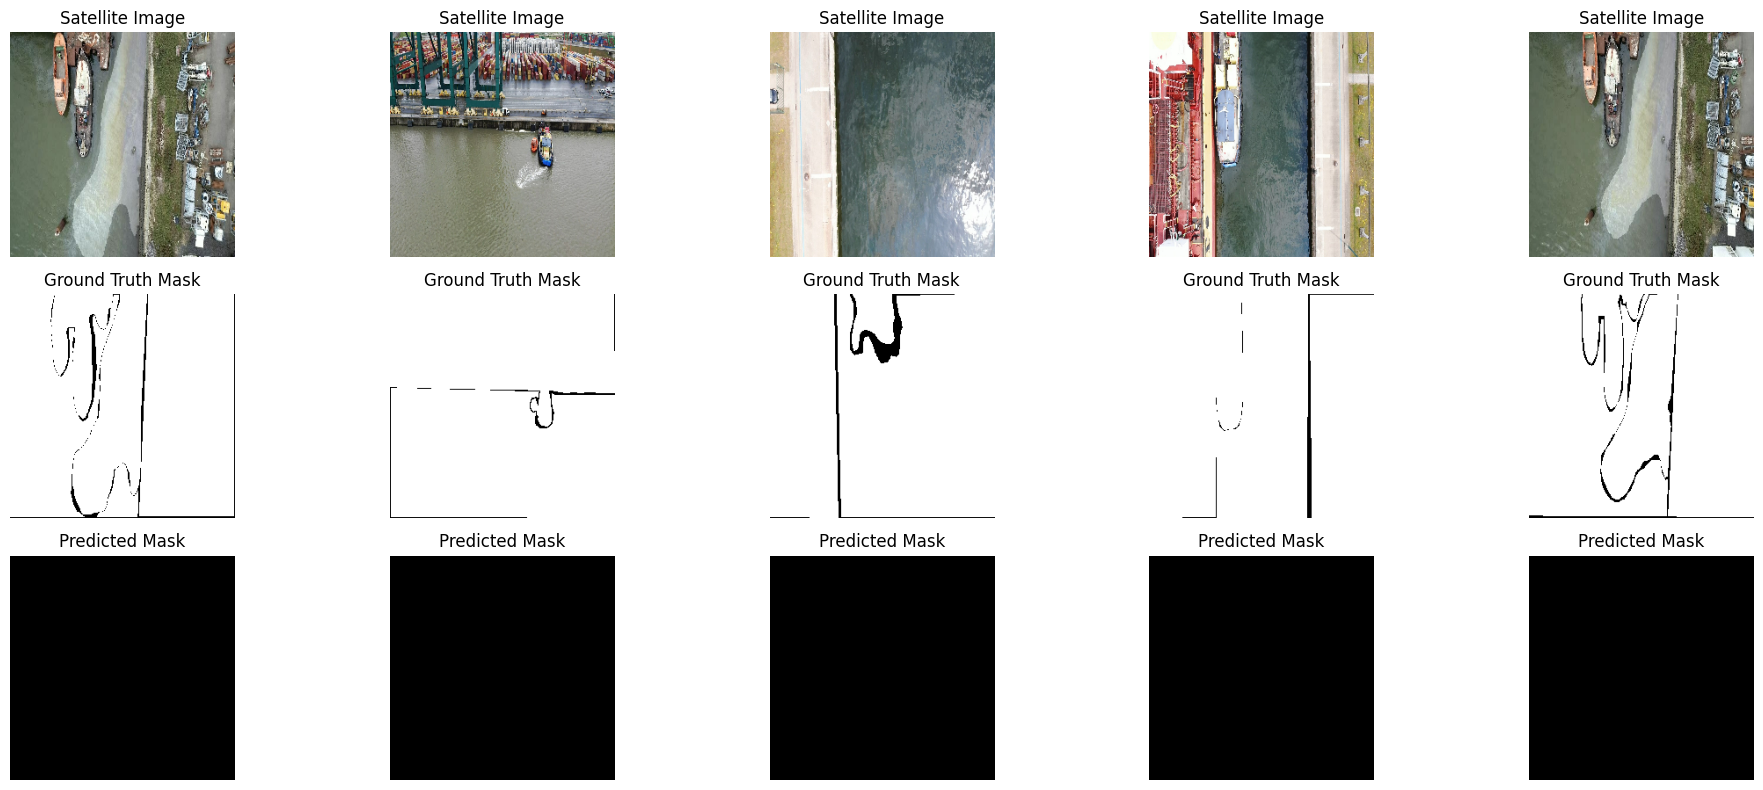

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def postprocess_mask(mask):
    mask = (mask > 0.5).astype('uint8')
    return mask

def predict_mask(model, img):
    pred_soft = model.predict(np.expand_dims(img, axis=0))[0,:,:,0]
    pred_mask = postprocess_mask(pred_soft)
    return pred_mask, pred_soft

def visualize_predictions(model, dataset, num_samples=5):
    for img_batch, mask_batch in dataset.take(1):
        plt.figure(figsize=(num_samples*4, 8))
        for i in range(num_samples):
            img = img_batch[i].numpy()
            true_mask = mask_batch[i].numpy().squeeze()
            pred_mask, _ = predict_mask(model, img)

            plt.subplot(3, num_samples, i+1)
            plt.imshow(img)
            plt.title("Satellite Image")
            plt.axis("off")

            plt.subplot(3, num_samples, num_samples+i+1)
            plt.imshow(true_mask, cmap="gray")
            plt.title("Ground Truth Mask")
            plt.axis("off")

            plt.subplot(3, num_samples, 2*num_samples+i+1)
            plt.imshow(pred_mask, cmap="gray")
            plt.title("Predicted Mask")
            plt.axis("off")

        plt.tight_layout()
        plt.show()

# Example usage:
visualize_predictions(model, test_dataset, num_samples=5)


Contour Overlay

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


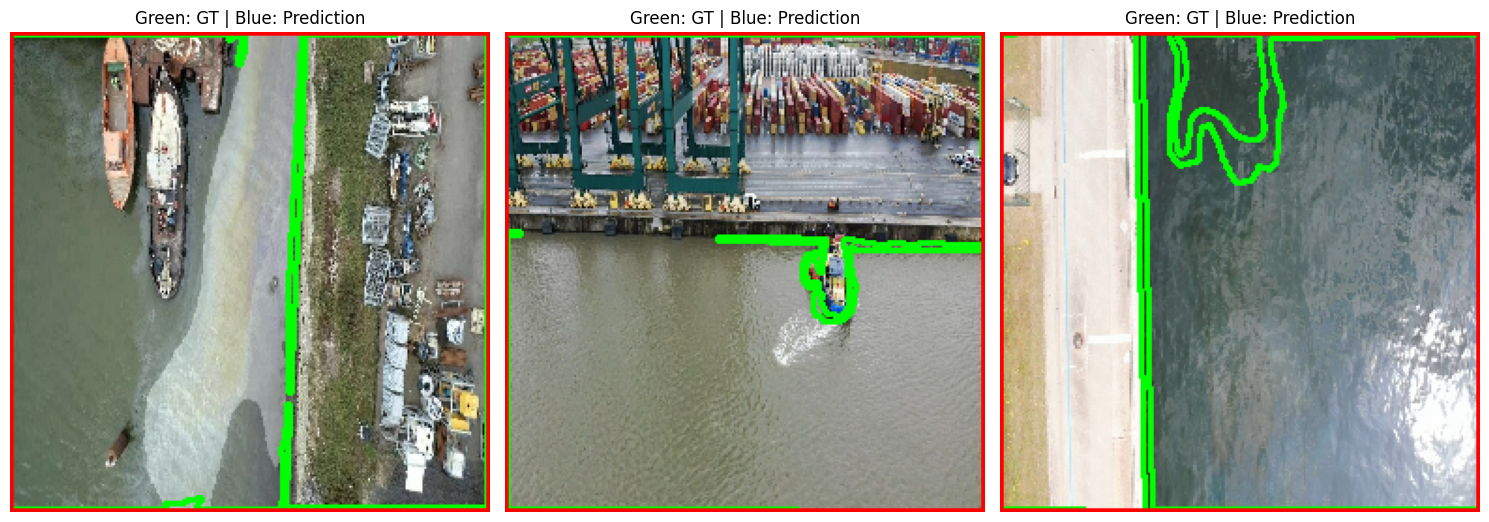

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def contour_overlay(model, dataset, num_samples=3):
    for images, masks in dataset.take(1):
        preds = model.predict(images)
        preds = (preds > 0.5).astype(np.uint8)

        plt.figure(figsize=(15, num_samples * 4))
        for i in range(num_samples):
            img = (images[i].numpy() * 255).astype(np.uint8)
            mask = masks[i].numpy().squeeze()
            pred = preds[i].squeeze()

            contours_gt, _ = cv2.findContours(mask.astype('uint8'), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            contours_pred, _ = cv2.findContours(pred.astype('uint8'), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            overlay = img.copy()
            cv2.drawContours(overlay, contours_gt, -1, (0, 255, 0), 2)
            cv2.drawContours(overlay, contours_pred, -1, (255, 0, 0), 2)

            plt.subplot(1, num_samples, i+1)
            plt.imshow(overlay)
            plt.title("Green: GT | Blue: Prediction")
            plt.axis("off")

        plt.tight_layout()
        plt.show()

# Example usage:
contour_overlay(model, test_dataset, num_samples=3)


Prediction Confidence Heatmap

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


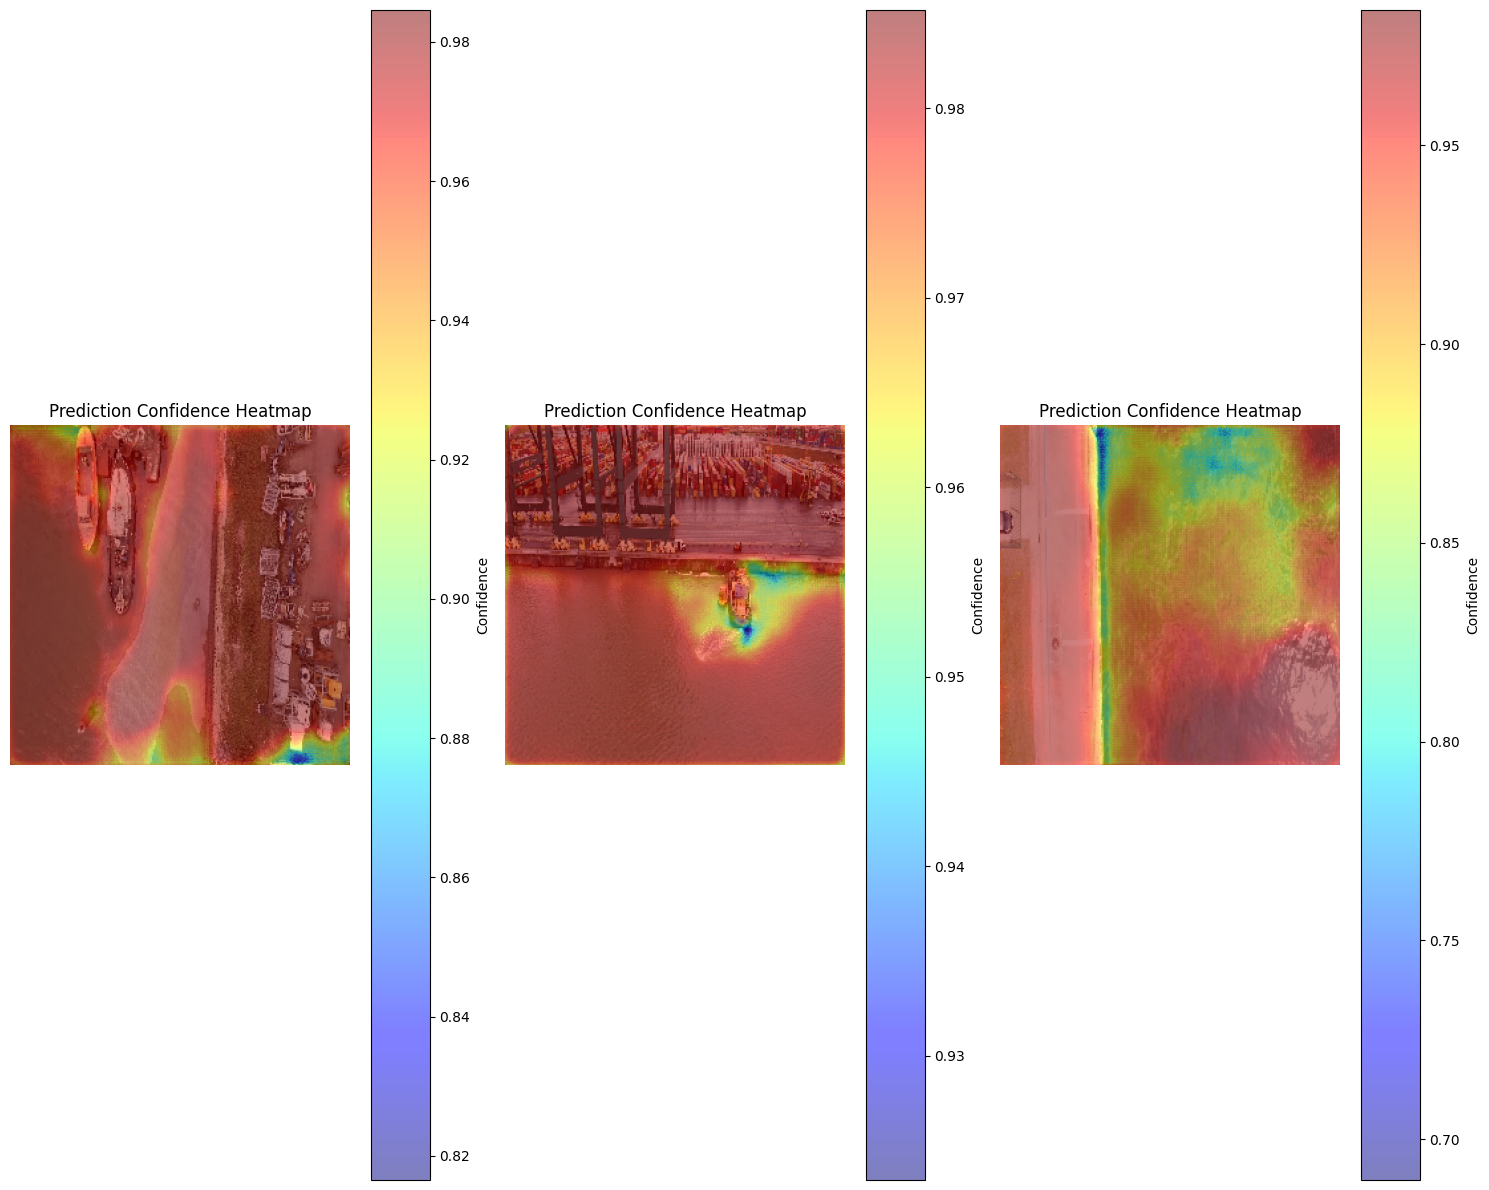

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def confidence_heatmap(model, dataset, num_samples=3, cmap='jet'):
    for images, _ in dataset.take(1):
        preds = model.predict(images)
        preds = np.clip(preds, 0, 1)

        plt.figure(figsize=(15, num_samples * 4))
        for i in range(num_samples):
            img = (images[i].numpy() * 255).astype(np.uint8)
            conf_map = preds[i].squeeze()

            plt.subplot(1, num_samples, i+1)
            plt.imshow(img)
            plt.imshow(conf_map, cmap=cmap, alpha=0.5)
            plt.colorbar(label="Confidence")
            plt.title("Prediction Confidence Heatmap")
            plt.axis("off")

        plt.tight_layout()
        plt.show()

# Example usage:
confidence_heatmap(model, test_dataset, num_samples=3)


Colored Error Map

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


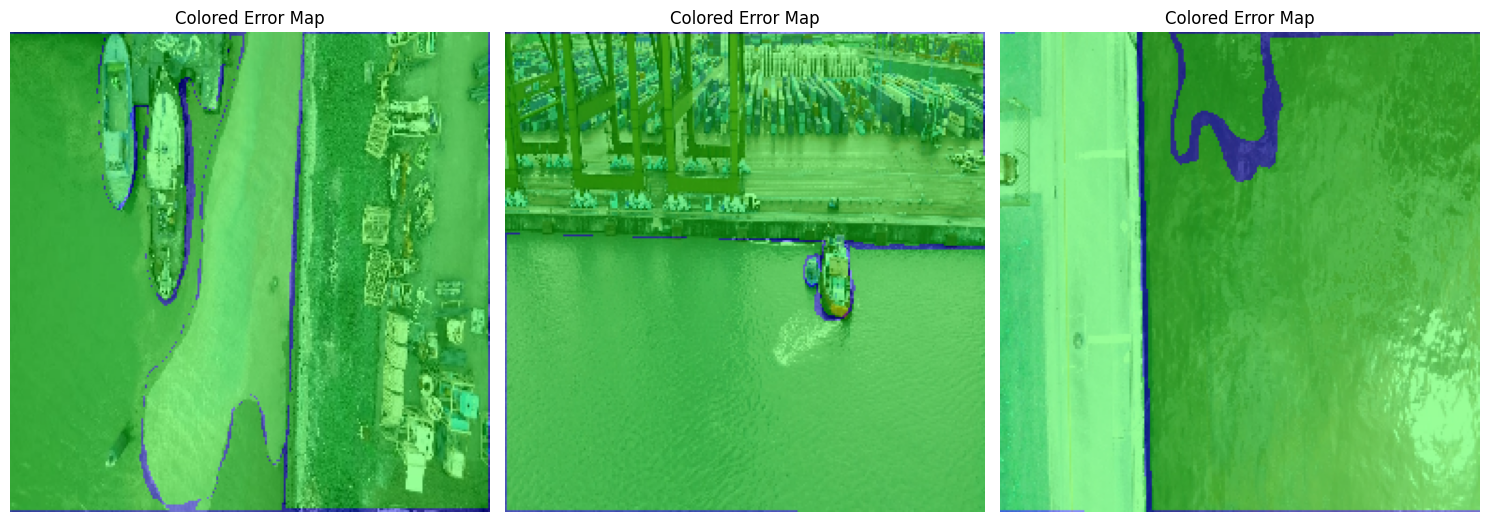

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

def colored_error_map(model, dataset, num_samples=3):
    for images, masks in dataset.take(1):
        preds = model.predict(images)
        preds = (preds > 0.5).astype(np.uint8)

        plt.figure(figsize=(15, num_samples * 4))
        for i in range(num_samples):
            img = (images[i].numpy() * 255).astype(np.uint8)
            mask = masks[i].numpy().squeeze()
            pred = preds[i].squeeze()

            tp = (pred==1) & (mask==1)
            fp = (pred==1) & (mask==0)
            fn = (pred==0) & (mask==1)

            color_map = np.zeros_like(img)
            color_map[tp] = [0, 255, 0]
            color_map[fp] = [255, 0, 0]
            color_map[fn] = [0, 255, 255]

            overlay = cv2.addWeighted(img, 0.6, color_map, 0.4, 0)
            plt.subplot(1, num_samples, i+1)
            plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
            plt.title("Colored Error Map")
            plt.axis("off")

        plt.tight_layout()
        plt.show()

# Example usage:
colored_error_map(model, test_dataset, num_samples=3)


Predicted Area Distribution

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


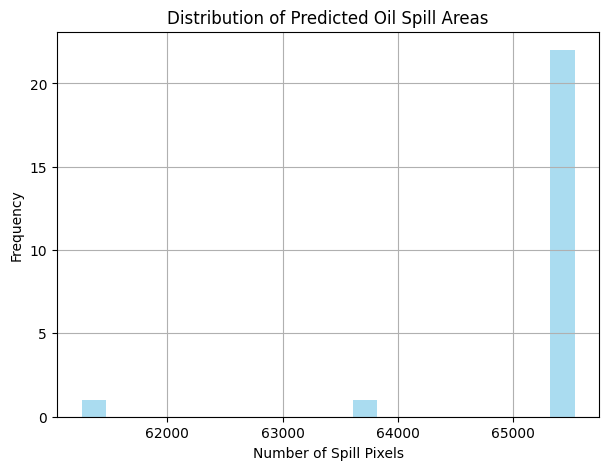

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_area_distribution(model, dataset, num_samples=3):
    areas = []
    for images, _ in dataset.take(num_samples):
        preds = model.predict(images)
        preds = (preds > 0.5).astype(np.uint8)
        for i in range(len(preds)):
            areas.append(np.sum(preds[i]))

    plt.figure(figsize=(7,5))
    plt.hist(areas, bins=20, color='skyblue', alpha=0.7)
    plt.title("Distribution of Predicted Oil Spill Areas")
    plt.xlabel("Number of Spill Pixels")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

# Example usage:
plot_area_distribution(model, test_dataset, num_samples=3)


Training Curves

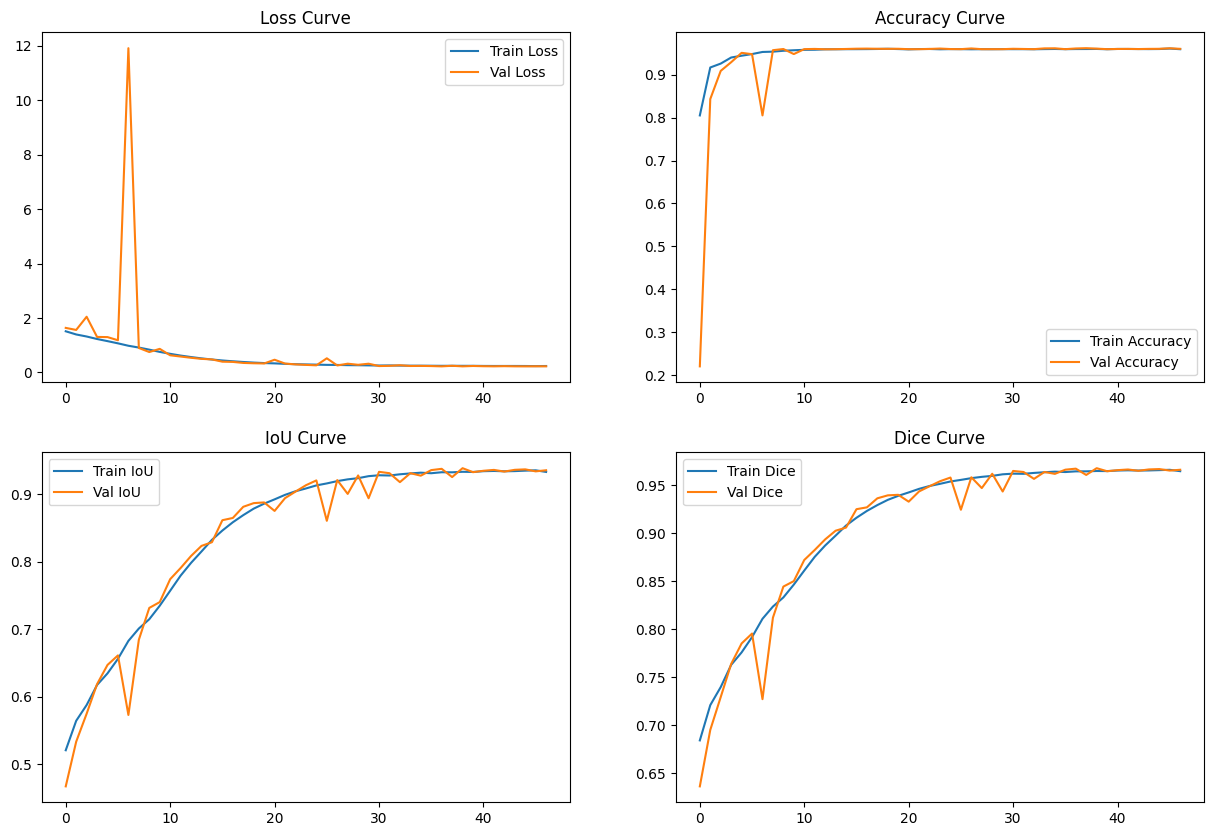

In [ ]:
import matplotlib.pyplot as plt

def plot_training_curves(history):
    plt.figure(figsize=(15,10))

    # Loss
    plt.subplot(2,2,1)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title("Loss Curve")
    plt.legend()

    # Accuracy
    plt.subplot(2,2,2)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Val Accuracy")
    plt.title("Accuracy Curve")
    plt.legend()

    # IoU
    plt.subplot(2,2,3)
    plt.plot(history.history["iou_coefficient"], label="Train IoU")
    plt.plot(history.history["val_iou_coefficient"], label="Val IoU")
    plt.title("IoU Curve")
    plt.legend()

    # Dice
    plt.subplot(2,2,4)
    plt.plot(history.history["dice_coefficient"], label="Train Dice")
    plt.plot(history.history["val_dice_coefficient"], label="Val Dice")
    plt.title("Dice Curve")
    plt.legend()

    plt.show()

# Example usage:
plot_training_curves(history)


Test Metrics Bar Plot

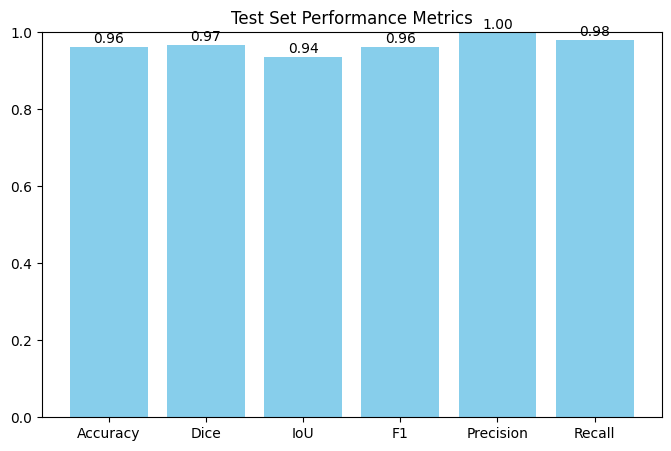

In [ ]:
import matplotlib.pyplot as plt

def plot_test_metrics(results):
    metrics = {
        'Accuracy': results[1],
        'Dice': results[2],
        'IoU': results[3],
        'F1': results[4],
        'Precision': results[5],
        'Recall': results[6]
    }

    plt.figure(figsize=(8,5))
    plt.bar(metrics.keys(), metrics.values(), color='skyblue')
    plt.ylim(0,1)
    plt.title("Test Set Performance Metrics")
    for i,v in enumerate(metrics.values()):
        plt.text(i, v+0.01, f"{v:.2f}", ha='center')
    plt.show()

# Example usage:
plot_test_metrics(results)


In [ ]:
!pip install pyngrok --quiet
from pyngrok import ngrok

# Paste your token inside quotes ↓
ngrok.set_auth_token("343fnt00EYAAQEq9kcWt3hacKQf_4agSgV44wqMbo645RE6CL")

print("✅ Ngrok authentication successful!")


✅ Ngrok authentication successful!


In [ ]:
# Colab cell
!apt-get update -y >/dev/null
!pip install -q fastapi "uvicorn[standard]" python-multipart sqlalchemy aiosqlite pillow numpy opencv-python-headless \
    pyngrok requests streamlit plotly fpdf tensorflow==2.19.0
# localtunnel cli for exposing streamlit (optional)
!npm install -g localtunnel >/dev/null 2>&1 || true


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 517.7/517.7 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 456.8/456.8 kB 25.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
# <<< EDIT THESE if your model path or input size differ >>>
MODEL_FILE = "/content/drive/MyDrive/oil_spill_detection/best_model.h5"  # path to your .h5
MODEL_INPUT_SIZE = (256, 256)  # (width, height) expected by your model

# Persistence locations (Drive)
BASE_SAVE = "/content/drive/MyDrive/oil_spill_detection"
SAVE_FOLDER = os.path.join(BASE_SAVE, "uploads")
DB_FILE = os.path.join(BASE_SAVE, "inference_logs.db")
os.makedirs(SAVE_FOLDER, exist_ok=True)

print("MODEL_FILE:", MODEL_FILE)
print("MODEL_INPUT_SIZE:", MODEL_INPUT_SIZE)
print("SAVE_FOLDER:", SAVE_FOLDER)
print("DB_FILE:", DB_FILE)


MODEL_FILE: /content/drive/MyDrive/oil_spill_detection/best_model.h5
MODEL_INPUT_SIZE: (256, 256)
SAVE_FOLDER: /content/drive/MyDrive/oil_spill_detection/uploads
DB_FILE: /content/drive/MyDrive/oil_spill_detection/inference_logs.db


In [ ]:
%%writefile app.py
import os, io, time, uuid
from datetime import datetime
from fastapi import FastAPI, File, UploadFile, HTTPException
from fastapi.responses import JSONResponse, FileResponse, RedirectResponse
from fastapi.middleware.cors import CORSMiddleware
from sqlalchemy import create_engine, Column, Integer, String, Float, DateTime, Text
from sqlalchemy.ext.declarative import declarative_base
from sqlalchemy.orm import sessionmaker
from PIL import Image
import numpy as np
import tensorflow as tf
import cv2
import requests

# ---------- CONFIG (override with env vars if needed) ----------
MODEL_PATH = os.environ.get("MODEL_PATH", "{MODEL_FILE}")
SAVE_FOLDER = os.environ.get("SAVE_FOLDER", "{SAVE_FOLDER}")
DB_PATH = os.environ.get("DB_PATH", "sqlite:///{DB_FILE}")
INPUT_SIZE = tuple(map(int, os.environ.get("INPUT_SIZE", "{w},{h}".split(","))))
ALERT_WEBHOOK = os.environ.get("ALERT_WEBHOOK", "")  # e.g. "https://hooks.example.com/..."
ALERT_THRESHOLD = float(os.environ.get("ALERT_THRESHOLD", "0.2"))  # fraction threshold to trigger webhook
# ------------------------------------------------------------------

os.makedirs(SAVE_FOLDER, exist_ok=True)

# Database setup
engine = create_engine(DB_PATH, connect_args={"check_same_thread": False})
SessionLocal = sessionmaker(autocommit=False, autoflush=False, bind=engine)
Base = declarative_base()

class InferenceLog(Base):
    __tablename__ = "inference_logs"
    id = Column(Integer, primary_key=True, index=True)
    request_id = Column(String, unique=True, index=True)
    filename = Column(String)
    uploaded_at = Column(DateTime)
    result_summary = Column(Text)
    score = Column(Float, nullable=True)
    saved_path = Column(String, nullable=True)

Base.metadata.create_all(bind=engine)

# FastAPI app
app = FastAPI(title="Oil Spill Detection API")
app.add_middleware(CORSMiddleware, allow_origins=["*"], allow_credentials=True, allow_methods=["*"], allow_headers=["*"])

# Load model
print("Loading model from:", MODEL_PATH)
try:
    # if model uses custom objects, load code here or set reload in env
    model = tf.keras.models.load_model(MODEL_PATH, compile=False)
    model_loaded = True
    print("Model loaded.")
except Exception as e:
    print("Failed to load model:", e)
    model = None
    model_loaded = False

@app.get("/")
def root():
    return RedirectResponse(url="/docs")

@app.get("/health")
def health():
    return {"ok": True, "model_loaded": model_loaded}

def preprocess_image(pil_img, target_size):
    img = pil_img.convert("RGB").resize(target_size, Image.BILINEAR)
    arr = np.array(img).astype("float32") / 255.0
    return np.expand_dims(arr, axis=0)

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    if not model_loaded:
        raise HTTPException(status_code=500, detail="Model not loaded.")
    content = await file.read()
    try:
        pil = Image.open(io.BytesIO(content)).convert("RGB")
    except Exception as e:
        raise HTTPException(status_code=400, detail=f"Invalid image: {e}")

    # Preprocess
    try:
        target_size = INPUT_SIZE
        arr = preprocess_image(pil, target_size)
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"Preprocess error: {e}")

    # Inference
    start = time.time()
    pred = model.predict(arr)
    elapsed = time.time() - start

    # Postprocess - assume segmentation mask output [1,H,W,1] or [1,H,W]
    try:
        mask = pred[0]
        if mask.ndim == 3 and mask.shape[-1] == 1:
            mask = mask[...,0]
        mask = np.clip(mask, 0, 1)
        mask_bin = (mask > 0.5).astype(np.uint8)
        score = float(mask_bin.mean())
    except Exception as e:
        mask_bin = None
        score = None

    # Save original image
    rid = str(uuid.uuid4())
    fname = f"{rid}__{file.filename}"
    save_path = os.path.join(SAVE_FOLDER, fname)
    with open(save_path, "wb") as f:
        f.write(content)

    # Save mask as PNG resized to original image size
    mask_path = None
    if mask_bin is not None:
        try:
            mask_u8 = (mask_bin * 255).astype("uint8")
            mask_img = Image.fromarray(mask_u8)
            mask_img = mask_img.resize(pil.size)
            mask_path = os.path.join(SAVE_FOLDER, f"{rid}__mask_{file.filename}.png")
            mask_img.save(mask_path)
        except Exception as e:
            print("Mask save failed:", e)
            mask_path = None

    # DB log
    db = SessionLocal()
    log = InferenceLog(request_id=rid, filename=file.filename, uploaded_at=datetime.utcnow(),
                       result_summary=str({"score": score}), score=score, saved_path=save_path)
    db.add(log)
    db.commit()
    db.refresh(log)
    db.close()

    # Webhook alert if configured and score above threshold
    if ALERT_WEBHOOK and score is not None and score >= ALERT_THRESHOLD:
        try:
            requests.post(ALERT_WEBHOOK, json={"request_id": rid, "filename": file.filename, "score": score}, timeout=3)
        except Exception as e:
            print("Webhook failed:", e)

    return JSONResponse({
        "request_id": rid,
        "filename": file.filename,
        "uploaded_at": datetime.utcnow().isoformat()+"Z",
        "elapsed_seconds": elapsed,
        "summary": {"oil_pixel_fraction": score},
        "score": score,
        "saved_path": save_path,
        "mask_preview": f"/mask/{rid}"
    })

@app.get("/mask/{request_id}")
def get_mask(request_id: str):
    for name in os.listdir(SAVE_FOLDER):
        if name.startswith(request_id) and "mask_" in name:
            return FileResponse(os.path.join(SAVE_FOLDER, name))
    raise HTTPException(status_code=404, detail="Mask not found")

@app.get("/logs")
def get_logs(limit: int = 50):
    db = SessionLocal()
    rows = db.query(InferenceLog).order_by(InferenceLog.uploaded_at.desc()).limit(limit).all()
    res = [{"request_id": r.request_id, "filename": r.filename, "uploaded_at": r.uploaded_at.isoformat()+"Z", "summary": r.result_summary, "score": r.score} for r in rows]
    db.close()
    return {"count": len(res), "results": res}


Writing app.py


In [ ]:
# Replace placeholders in app.py (safety)
text = open("app.py","r").read()
text = text.replace("{MODEL_FILE}", MODEL_FILE).replace("{SAVE_FOLDER}", SAVE_FOLDER).replace("{DB_FILE}", DB_FILE)
w,h = MODEL_INPUT_SIZE
text = text.replace("{w}", str(w)).replace("{h}", str(h)).replace('tuple(map(int, os.environ.get("INPUT_SIZE", "{w},{h}".split(","))))', f'({w},{h})')
open("app.py","w").write(text)
print("app.py updated with your MODEL_FILE, SAVE_FOLDER, DB_FILE, and INPUT_SIZE.")


app.py updated with your MODEL_FILE, SAVE_FOLDER, DB_FILE, and INPUT_SIZE.


In [ ]:
%%writefile streamlit_app.py
import streamlit as st
import numpy as np
import cv2
import os
from PIL import Image
import io
import matplotlib.pyplot as plt
import requests
from fpdf import FPDF# -----------------------------
# 1️⃣ Load the model ONCE using cache
# -----------------------------




# ------------------ CONFIG ------------------
# Default backend URL will be set by you after starting backend (ngrok). You can paste it in sidebar.
DEFAULT_BACKEND = "https://sixty-loops-grow.loca.lt"  # change to ngrok URL after backend started
IMG_SIZE = (256, 256)

# ------------------ PAGE SETUP ------------------
st.set_page_config(page_title="🛰 Oil Spill Detection", layout="wide")
st.markdown("""
    <style>
    .main {background-color: #f9fafb;}
    .stApp {background-color: #f0f2f6;}
    h1 {text-align:center; color:#003366;}
    </style>
""", unsafe_allow_html=True)

st.title("🛰 Oil Spill Detection Dashboard")
st.markdown("Upload a satellite image to visualize predicted oil spill regions and metrics.")

# ------------------ SIDEBAR ------------------
st.sidebar.header("⚙ Model & Settings")
backend_url = st.sidebar.text_input("Backend URL (ngrok/public URL)", value=DEFAULT_BACKEND)
use_local = st.sidebar.checkbox("Local inference (load model in frontend)", value=False)
model_path_input = st.sidebar.text_input("Local model path (if Local inference)", value="/content/best_model.h5")
threshold = st.sidebar.slider("Mask threshold (visual only)", 0.0, 1.0, 0.5, 0.01)
alpha_value = st.sidebar.slider("Heatmap Transparency", 0.1, 1.0, 0.5, 0.05)
show_confidence = st.sidebar.checkbox("Show confidence heatmap", value=True)
save_to_drive = st.sidebar.checkbox("Save results to Drive (frontend)", value=False)
drive_save_folder = st.sidebar.text_input("Drive Folder", "/content/drive/MyDrive/oil_spill_detection/predictions")

# ------------------ OPTIONAL LOCAL MODEL LOADING ------------------
local_model = None
if use_local:
    try:
        import tensorflow as tf
        local_model = tf.keras.models.load_model(model_path_input, compile=False)
        st.sidebar.success("Local model loaded.")
    except Exception as e:
        st.sidebar.error(f"Failed to load local model: {e}")
        use_local = False
        local_model = None

# ------------------ IMAGE UTILS ------------------
def preprocess_pil_image(pil_img, target_size=IMG_SIZE):
    img = pil_img.convert("RGB").resize(target_size, Image.BILINEAR)
    return np.array(img).astype("float32") / 255.0

def postprocess_pred(prob_map, threshold=0.5):
    mask = (prob_map >= threshold).astype(np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask

def overlay_mask_on_image(image_arr, mask, color=[255,0,0], alpha=0.4):
    overlay = image_arr.copy()
    overlay[mask==1] = color
    return cv2.addWeighted(image_arr, 1-alpha, overlay, alpha, 0)

# ------------------ FILE UPLOAD ------------------
uploaded = st.file_uploader("Upload a satellite image (jpg, png, tif)", type=["png","jpg","jpeg","tif"])

# ------------------ SAMPLE METRICS ------------------
st.sidebar.subheader("📊 Model Performance (Sample)")
sample_metrics = {"Accuracy": 0.982, "Dice": 0.965, "IoU": 0.953, "Precision": 0.971, "Recall": 0.964, "F1": 0.967}
for k,v in sample_metrics.items():
    st.sidebar.metric(k, f"{v:.3f}")

# ------------------ MAIN ------------------
if uploaded is not None:
    image = Image.open(uploaded).convert("RGB")
    orig_np = np.array(image).astype(np.uint8)
    st.image(image, caption="Uploaded Image", use_column_width=True)

    if use_local and local_model is not None:
        # run local inference (optional)
        with st.spinner("Running local model inference..."):
            inp = preprocess_pil_image(image)
            x = np.expand_dims(inp, axis=0)
            preds = local_model.predict(x)
            prob_map = preds[0,...,0] if preds.ndim==4 else preds[0]
            prob_map = np.clip(prob_map,0,1)
            prob_map_resized = cv2.resize((prob_map*255).astype(np.uint8), image.size)
            prob_norm = prob_map_resized.astype(np.float32)/255.0
            mask = postprocess_pred(prob_norm, threshold=threshold)
            mask_img = Image.fromarray((mask*255).astype('uint8')).convert("L")
            score = float(mask.mean())
    else:
        # send to backend
        with st.spinner("Sending image to backend for inference..."):
            try:
                res = requests.post("https://dirty-terms-return.loca.lt", files=files, timeout=120)

               # res = requests.post(f"{backend_url}/predict", files=files, timeout=120)
                if res.status_code != 200:
                    st.error(f"Backend error: {res.text}")
                    st.stop()
                data = res.json()
                score = data.get("score", 0.0) or 0.0
                mask_url = f"{backend_url}{data.get('mask_preview','')}"
                # fetch mask image
                mask_img = None
                try:
                    r2 = requests.get(mask_url, stream=True, timeout=10)
                    if r2.status_code == 200:
                        mask_img = Image.open(io.BytesIO(r2.content)).convert("L")
                        mask = (np.array(mask_img) > 127).astype(np.uint8)
                        prob_norm = np.array(mask_img).astype(np.float32)/255.0
                    else:
                        mask = np.zeros((image.size[1],image.size[0]), dtype=np.uint8)
                        prob_norm = np.zeros_like(mask).astype(np.float32)
                except Exception as e:
                    st.warning("Could not fetch mask from backend: " + str(e))
                    mask = np.zeros((image.size[1],image.size[0]), dtype=np.uint8)
                    prob_norm = np.zeros_like(mask).astype(np.float32)
            except Exception as e:
                st.error("Request to backend failed: " + str(e))
                st.stop()

    overlayed = overlay_mask_on_image(orig_np, mask, color=[255,0,0], alpha=0.45)

    # Tabs
    tab1, tab2, tab3, tab4 = st.tabs(["🖼 Overlay", "🔥 Confidence Map", "🎭 Binary Mask", "📊 Stats & Report"])

    with tab1:
        st.image(overlayed, caption="Prediction Overlay", use_column_width=True)

    with tab2:
        if show_confidence:
            fig, ax = plt.subplots(figsize=(6,6))
            ax.imshow(orig_np)
            ax.imshow(prob_norm, cmap="jet", alpha=alpha_value)
            ax.axis("off")
            st.pyplot(fig)

    with tab3:
        st.image((mask*255).astype(np.uint8), caption="Predicted Binary Mask", use_column_width=False)

    with tab4:
        area_pixels = int(mask.sum())
        total_pixels = mask.shape[0] * mask.shape[1]
        pct = area_pixels / total_pixels * 100
        st.metric("Predicted Oil Spill Area (%)", f"{pct:.4f}%")
        st.write(f"Score (pixel fraction): {score:.6f}")

        # PDF report
        def create_report(metrics, area_pct):
            pdf = FPDF()
            pdf.add_page()
            pdf.set_font("Arial", size=12)
            pdf.cell(200, 10, txt="Oil Spill Detection Report", ln=True, align='C')
            pdf.cell(200, 10, txt=f"Predicted Spill Area: {area_pct:.2f}%", ln=True)
            for k,v in metrics.items():
                pdf.cell(200, 10, txt=f"{k}: {v:.4f}", ln=True)
            file_path = "/content/oil_spill_report.pdf"
            pdf.output(file_path)
            return file_path

        if st.button("📄 Generate Report PDF"):
            path = create_report(sample_metrics, pct)
            with open(path, "rb") as f:
                st.download_button("⬇ Download Report", f, file_name="oil_spill_report.pdf")

    # Save to Drive option
    if save_to_drive:
        os.makedirs(drive_save_folder, exist_ok=True)
        base = os.path.splitext(uploaded.name)[0]
        Image.fromarray(overlayed).save(os.path.join(drive_save_folder, base+"_overlay.png"))
        Image.fromarray((mask*255).astype(np.uint8)).save(os.path.join(drive_save_folder, base+"_mask.png"))
        Image.fromarray((prob_norm*255).astype(np.uint8)).save(os.path.join(drive_save_folder, base+"_confidence.png"))
        st.success(f"✅ Saved results to: {drive_save_folder}")

else:
    st.info("⬆ Upload an image to run the prediction.")

st.markdown("---")
st.caption("Oil Spill Detection | Streamlit + FastAPI Integration | Developed with ❤ in Colab")


Overwriting streamlit_app.py


In [ ]:
# Colab cell 6: start backend
!nohup uvicorn app:app --host 0.0.0.0 --port 8000 --reload > uvicorn.log 2>&1 &
# show a few lines of log to ensure it started
#sleep 1
!tail -n 200 uvicorn.log || true


In [ ]:
# Colab cell 7: run localtunnel for backend
!npx localtunnel --port 8000


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦your url is: https://gold-ways-buy.loca.lt
^C


In [ ]:
!wget -q -O - ipv4.icanhazip.com

34.125.88.152


In [ ]:
# Colab cell 8: start Streamlit and expose it via LocalTunnel

# (1) Start Streamlit backend in background
!nohup streamlit run streamlit_app.py --server.port 8501 > streamlit.log 2>&1 &

# (2) Expose Streamlit frontend publicly
!npx localtunnel --port 8501


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹your url is: https://lemon-views-lick.loca.lt
^C
